# KDUQ corpus: proton elastic

The KDUQ corpus is a reconstruction of the experimental data used in the Koning-Delaroche global optical potential analysis, assembled from EXFOR by the supplement's authors and tabulated in Supplemental Material B.

Proton differential elastic scattering cross sections, stored as a ratio to Rutherford against CM scattering angle. EXFOR reports some of these data sets as ratios and others as absolute cross sections; the absolute ones are divided by the Rutherford cross section so the sector is uniform.

The subentries and scattering energies below are transcribed from the supplement's
tables into `spec/kduq_proton_elastic.csv`. Every row must be accounted for: it either
produces data, or it is listed in `spec/known_missing.csv` with a reason. Uncertainties
are assigned by the supplement's preference rule (`nn_corpora.errors`), and the
corrections its Comments describe are applied from `nn_corpora.overrides`.

In [1]:
%matplotlib inline
import matplotlib
from matplotlib import pyplot as plt

import pandas as pd

from nn_corpora import corpus, plotting, report, spec

pd.set_option("display.max_rows", 200)

Using database version X4-2025-12-31 located in: /mnt/home/beyerkyl/x4db/unpack_exfor-2025/X4-2025-12-31


## The specification

In [2]:
rows = spec.load_sector('kduq', 'proton_elastic')
print(f"{len(rows)} rows, {len({r.subentry for r in rows if r.in_exfor})} distinct subentries")
pd.DataFrame([vars(r) for r in rows]).head(15)

132 rows, 117 distinct subentries


,corpus,sector,projectile,target_A,target_Z,target_label,energy_mev,energy_hi_mev,subentry,pointer,pdf_page
0,kduq,proton_elastic,proton,27,13,27Al,17.0,None,O0262004,,14
1,kduq,proton_elastic,proton,27,13,27Al,28.0,None,C1208002,,14
2,kduq,proton_elastic,proton,27,13,27Al,35.2,None,O0083019,,14
3,kduq,proton_elastic,proton,27,13,27Al,61.4,None,O0211003,,14
4,kduq,proton_elastic,proton,27,13,27Al,142.0,None,O0247006,,14
5,kduq,proton_elastic,proton,27,13,27Al,156.0,None,O0049003,,14
6,kduq,proton_elastic,proton,27,13,27Al,160.0,None,D0283004,,14
7,kduq,proton_elastic,proton,27,13,27Al,183.0,None,O0365008,,14
8,kduq,proton_elastic,proton,28,14,28Si,17.8,None,O0254009,,14
9,kduq,proton_elastic,proton,28,14,28Si,28.0,None,C1208003,,14


## Retrieve and clean

`corpus.curate` retrieves each entry, matches measurements back to the rows that asked
for them, applies the documented corrections, and homogenises units and frames.

In [3]:
result = corpus.curate('kduq', 'proton_elastic')
print(result.summary())

kduq/proton_elastic
  spec rows              132
  ... marked absent      3
  ... resolved           121 / 129 (93.8%)
  measurements           115
  data points            4457
  EXFOR entries          48
  unresolved by category
    x4i3-parse-failure       6
    absent-from-exfor        3
    uncertainty-unresolved   2
  serialized             115 measurements, 4457 points
  dropped during cleaning
    O0211003: one or more data points carry no uncertainty
    O0300003: one or more data points carry no uncertainty
    O0393002: one or more data points carry no uncertainty
    O0393007: one or more data points carry no uncertainty
    O1198021: one or more data points carry no uncertainty
    O1243003: one or more data points carry no uncertainty


## Rows that did not resolve

Every row listed here must appear in `spec/known_missing.csv`, or the write below will
fail. The categories are: `absent-from-exfor` (the supplement itself marks the row as
not locatable), `x4i3-parse-failure` (the entry is in EXFOR but x4i3 cannot read it),
`subentry-withdrawn` (EXFOR has renumbered or removed the subentry since the supplement
was written), `energy-not-found`, and `uncertainty-unresolved`.

In [4]:
print(report.unresolved_table(result.data))

56Fe     10.930           [absent-from-exfor] the supplement marks this row as absent from EXFOR
56Fe     11.700           [absent-from-exfor] the supplement marks this row as absent from EXFOR
58Ni     11.700           [absent-from-exfor] the supplement marks this row as absent from EXFOR
209Bi    65.000 E0773008  [uncertainty-unresolved] uncertainty unresolved (no-uncertainty): subentry reports no uncertainty on the observable
28Si     40.000 O0162021  [x4i3-parse-failure] uncertainty unresolved (entry-unavailable): entry O0162 is not in the x4i3 index; it is most likely one of the entries x4i3 fails to parse
27Al     17.000 O0262004  [x4i3-parse-failure] parse failed: 'NoneType' object is not subscriptable
58Ni     17.000 O0262007  [x4i3-parse-failure] parse failed: 'NoneType' object is not subscriptable
90Zr     12.700 O0389002  [uncertainty-unresolved] uncertainty unresolved (unrecognised): no preferred uncertainty column among ['ERR-1', 'ERR-2']
58Ni     39.600 O0436003  [x4i3-pa

## Uncertainty audit

Data sets with missing uncertainties are dropped during munging, following the
supplement's removal of any data set lacking a necessary feature. This lists anything
that survived but still looks suspicious.

In [5]:
flags = plotting.check_uncertainties(result)
print("\n".join(flags) if flags else "every measurement carries uncertainties")

every measurement carries uncertainties


## Inspect

Every parsed data set is plotted, one figure per target, grouped by incident energy and
offset for legibility. Outliers here are found by eye: a mistranscribed point shows up
as a single datum an order of magnitude away from its neighbours; a badly normalised
data set shows up as a whole curve offset from others at the same energy. Nothing is
sampled or truncated -- the count of plotted data sets is checked against the number
written below, because a data set that is never drawn is one whose outliers are never
found.

plotted all 115 data sets


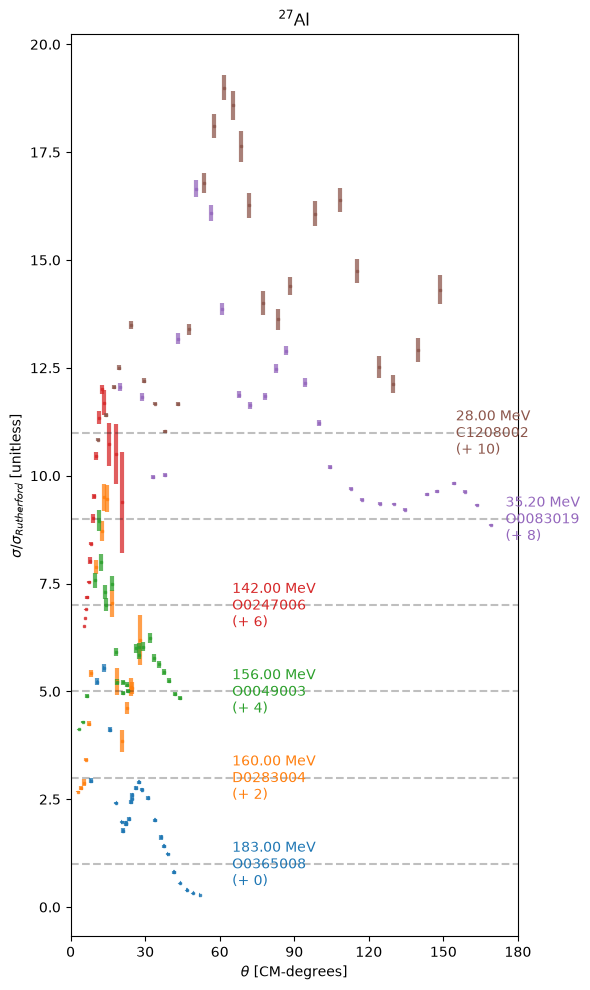

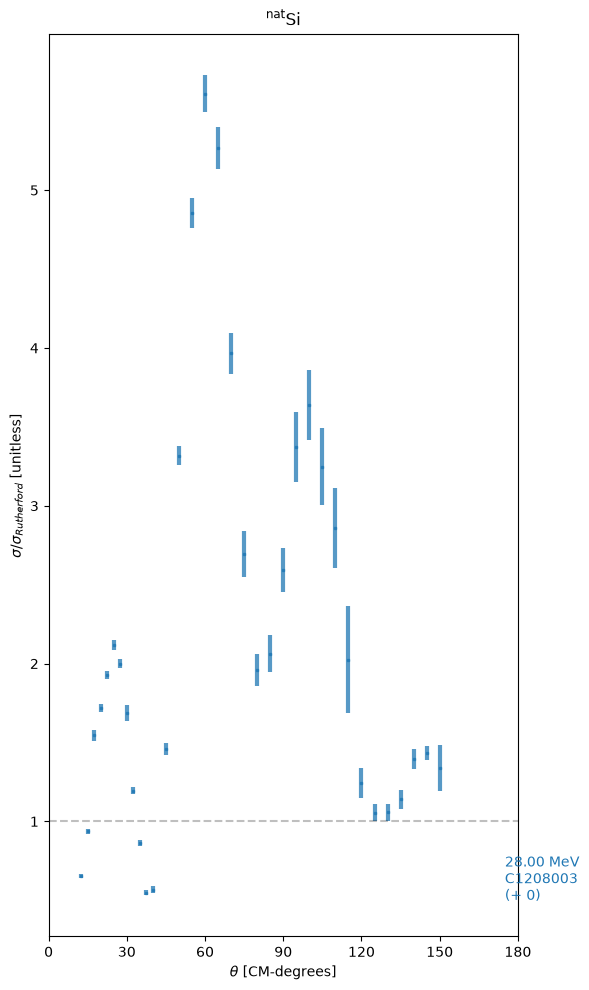

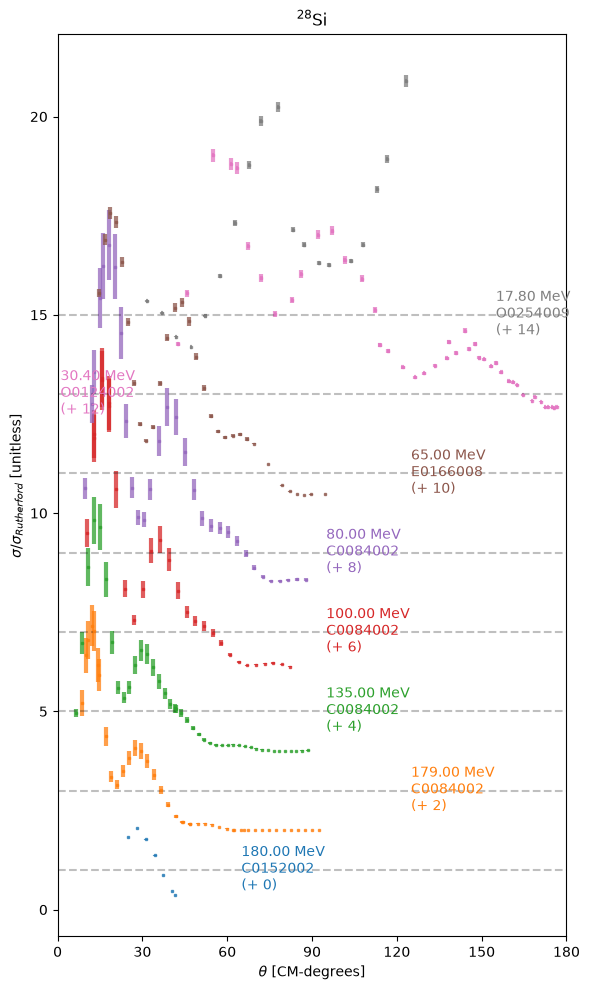

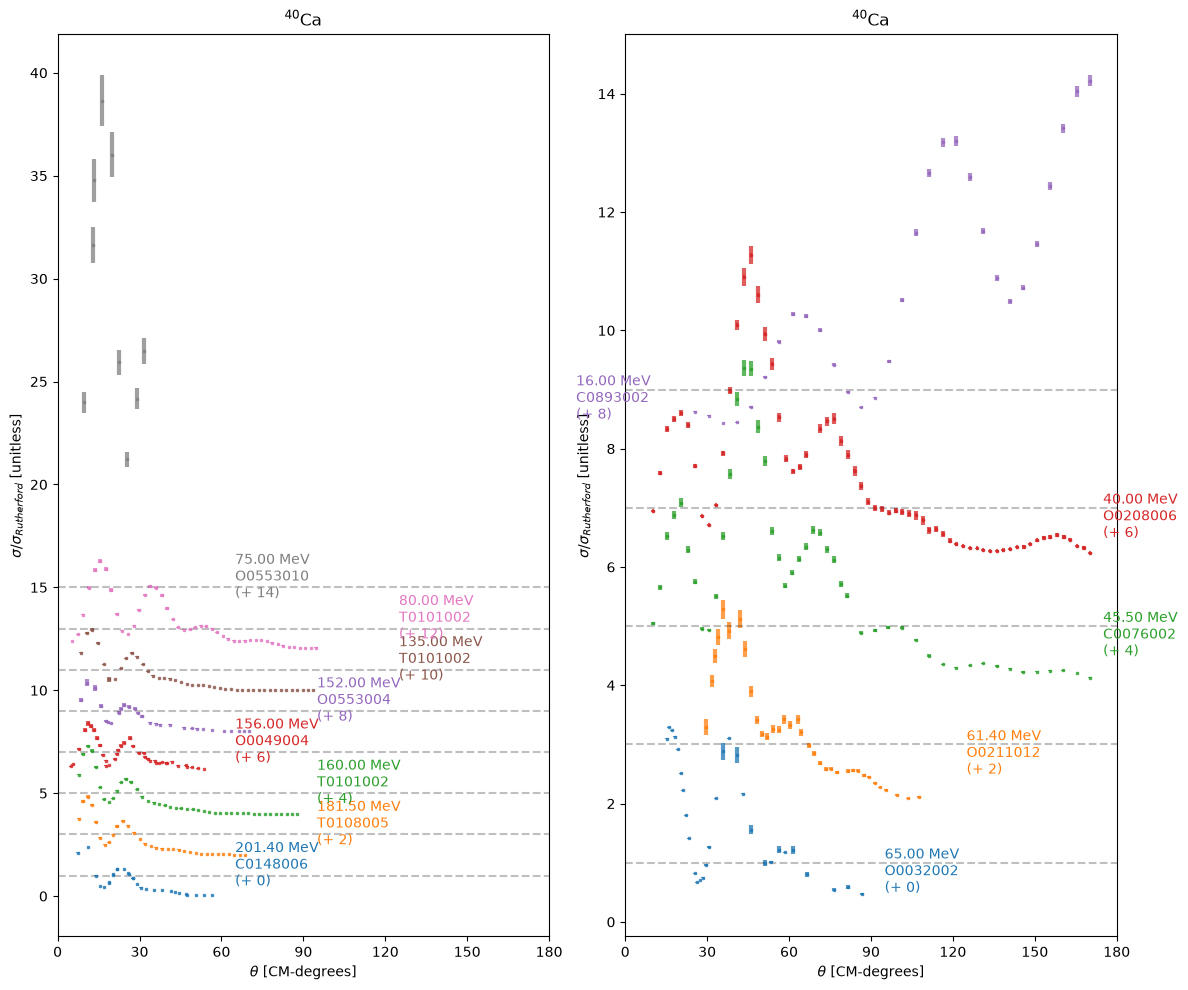

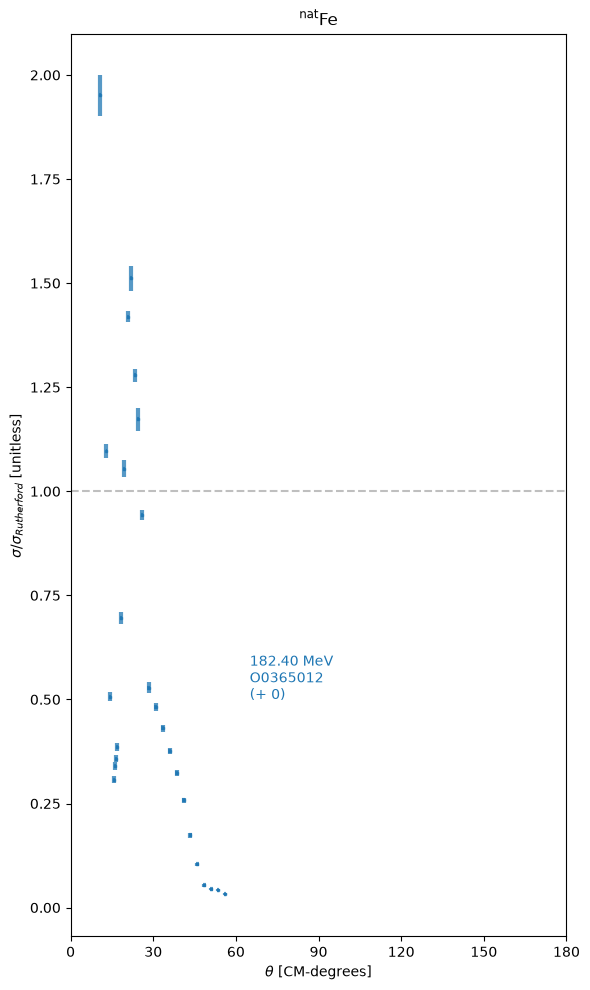

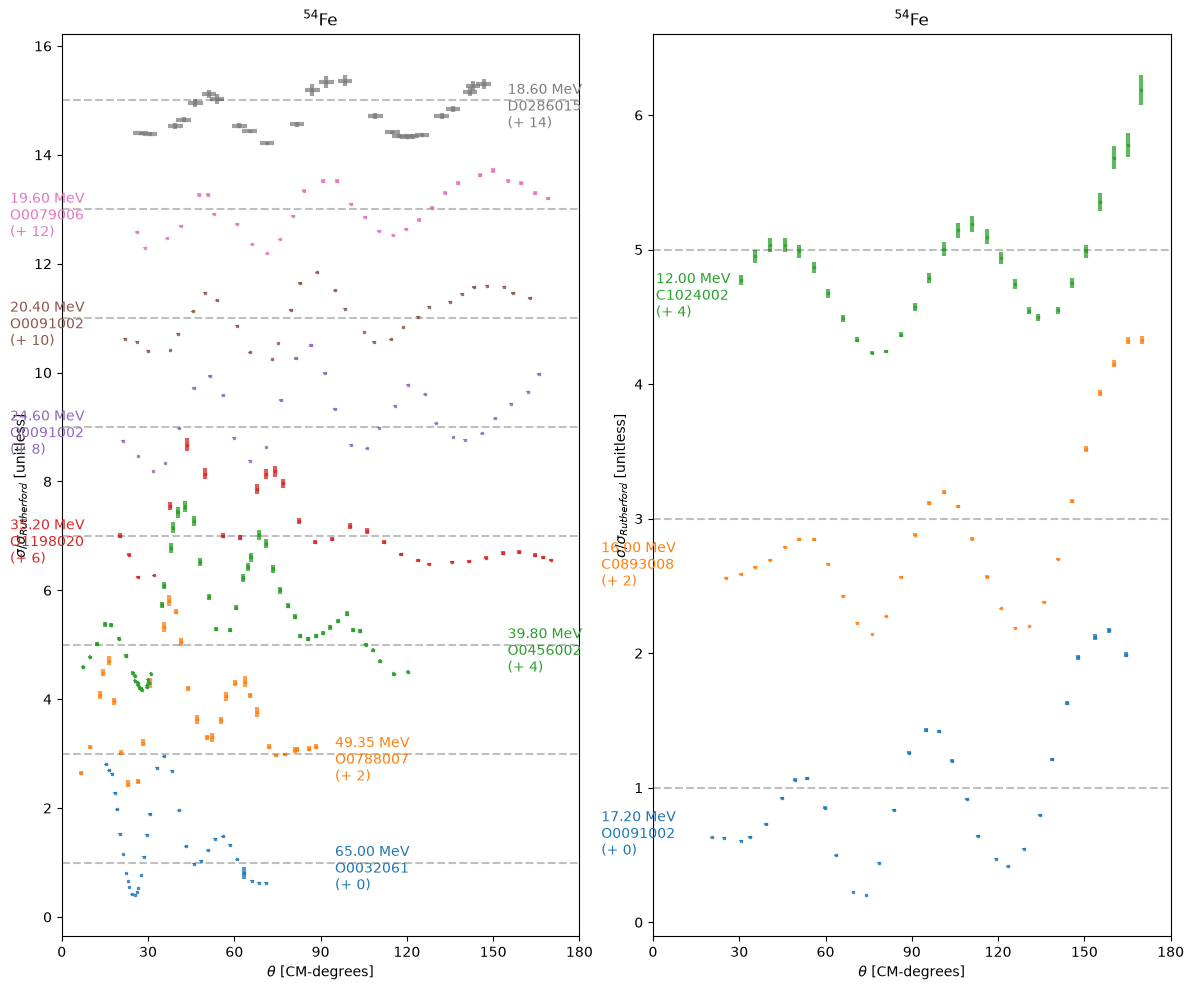

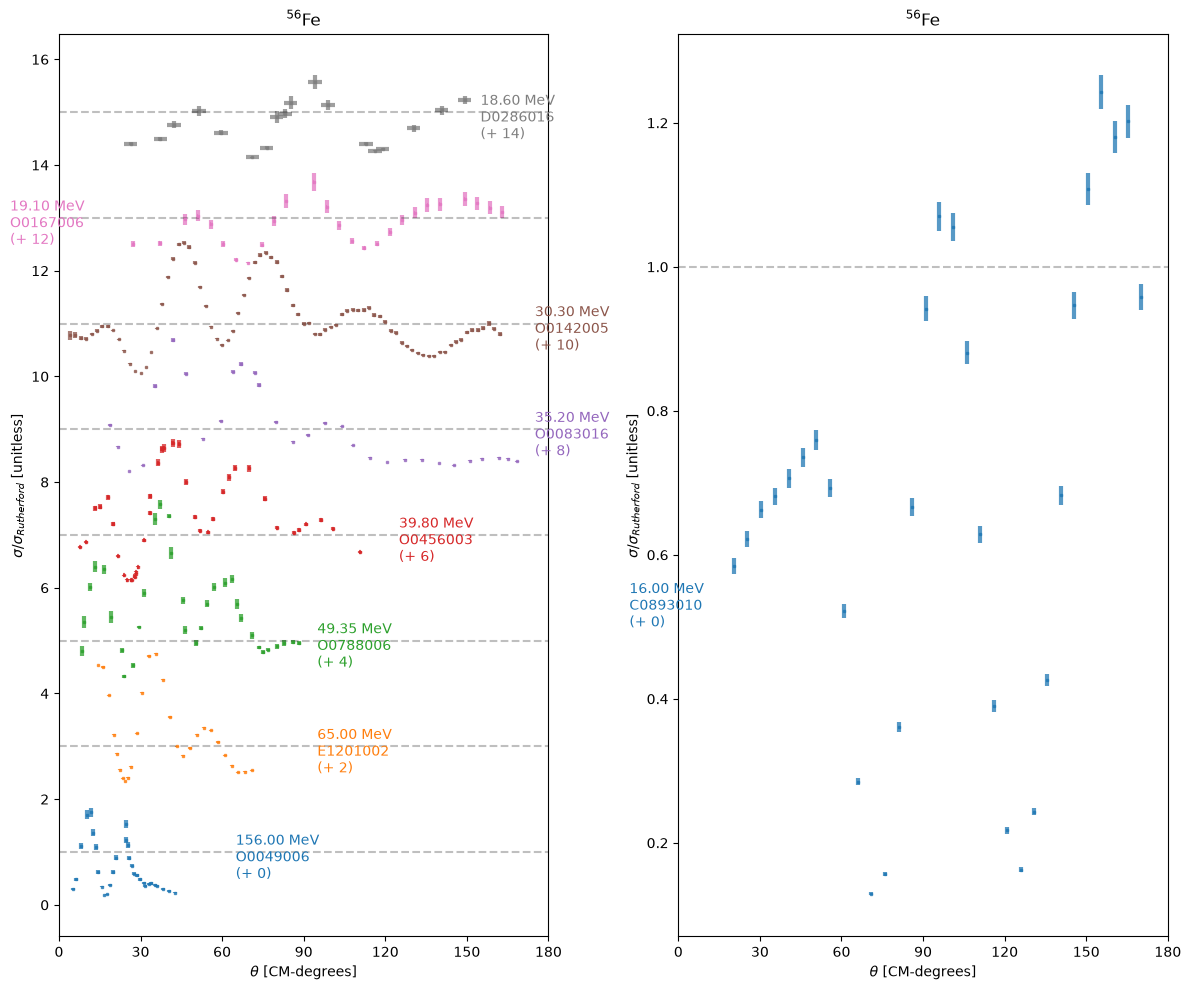

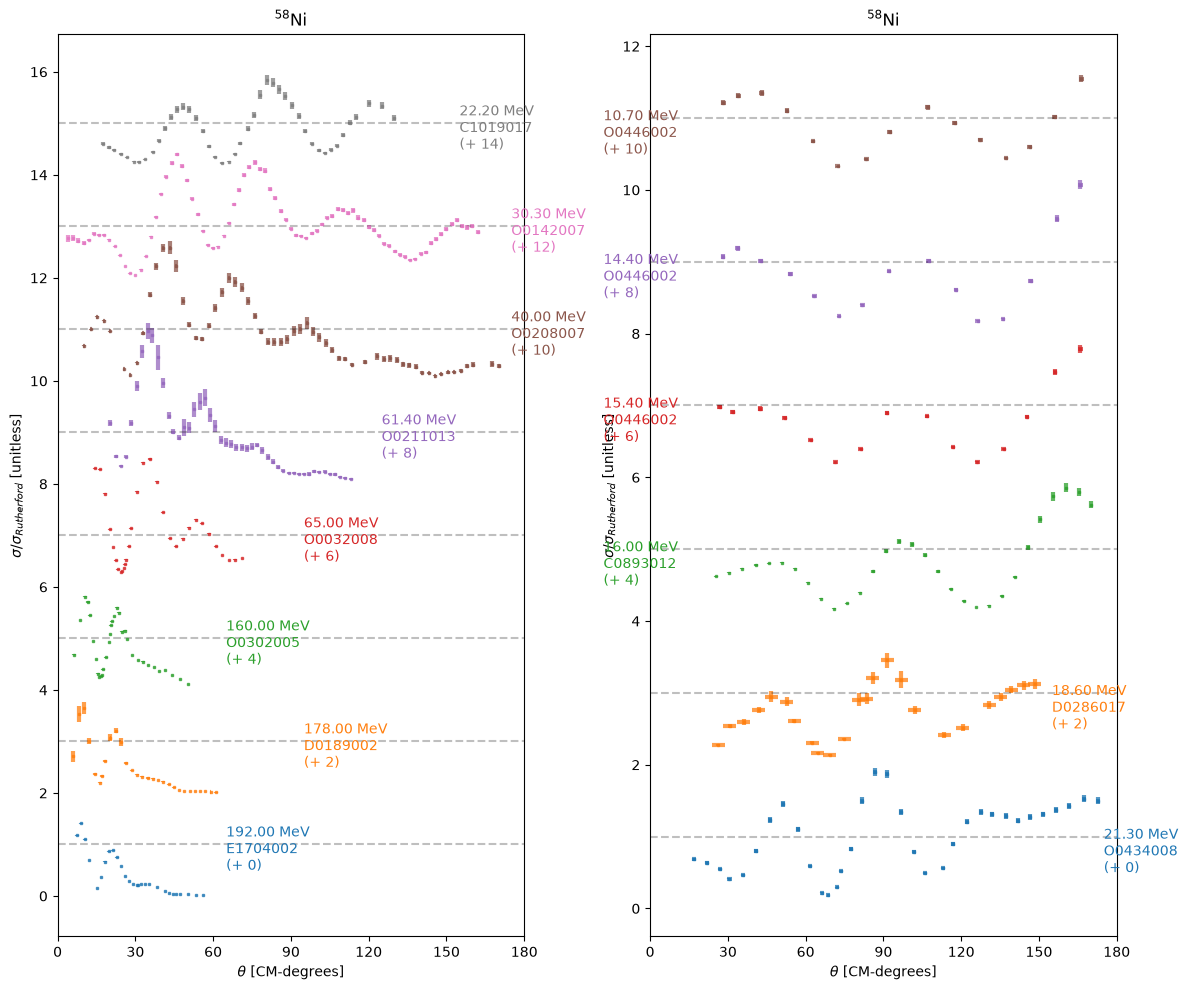

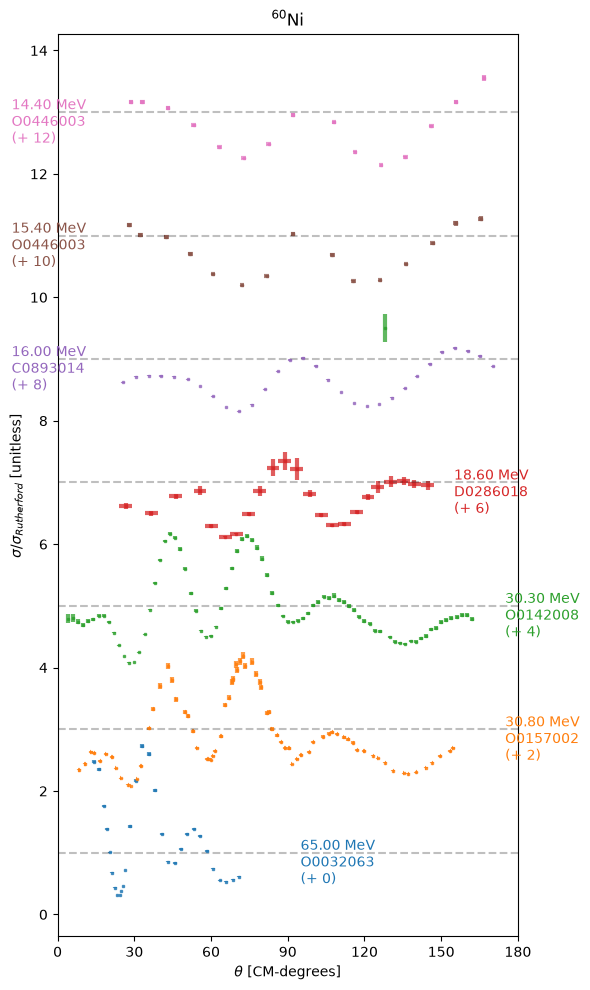

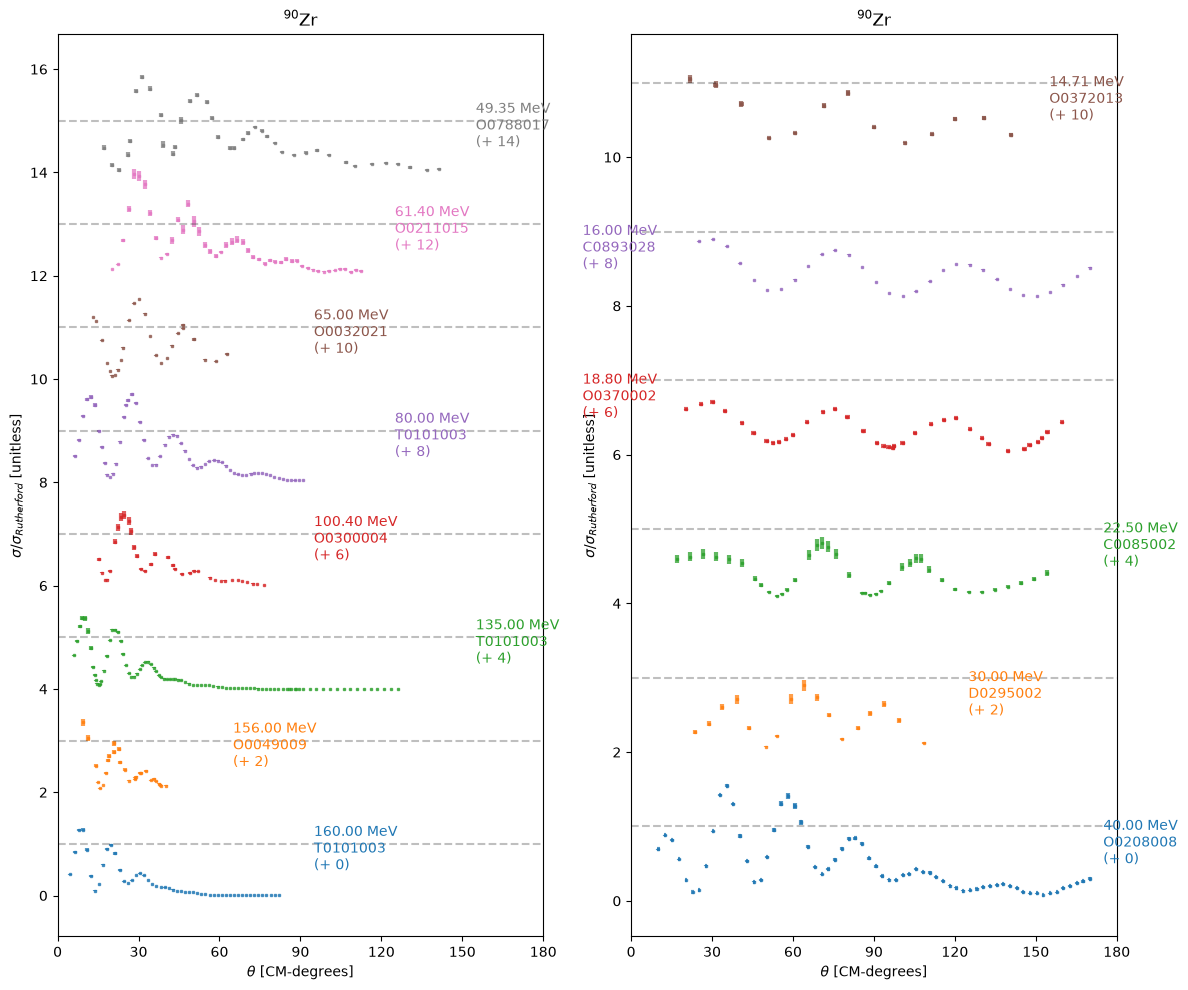

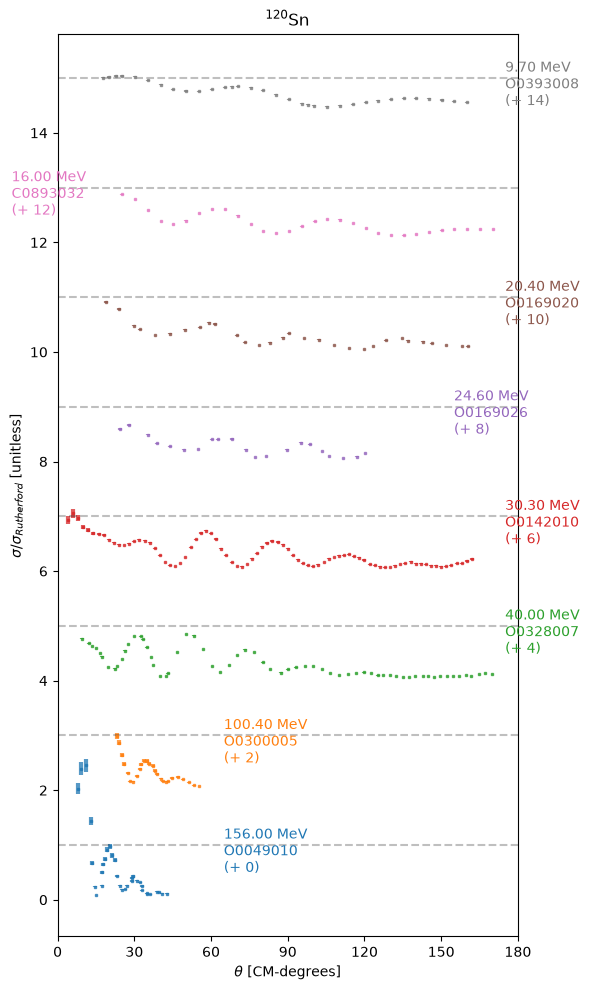

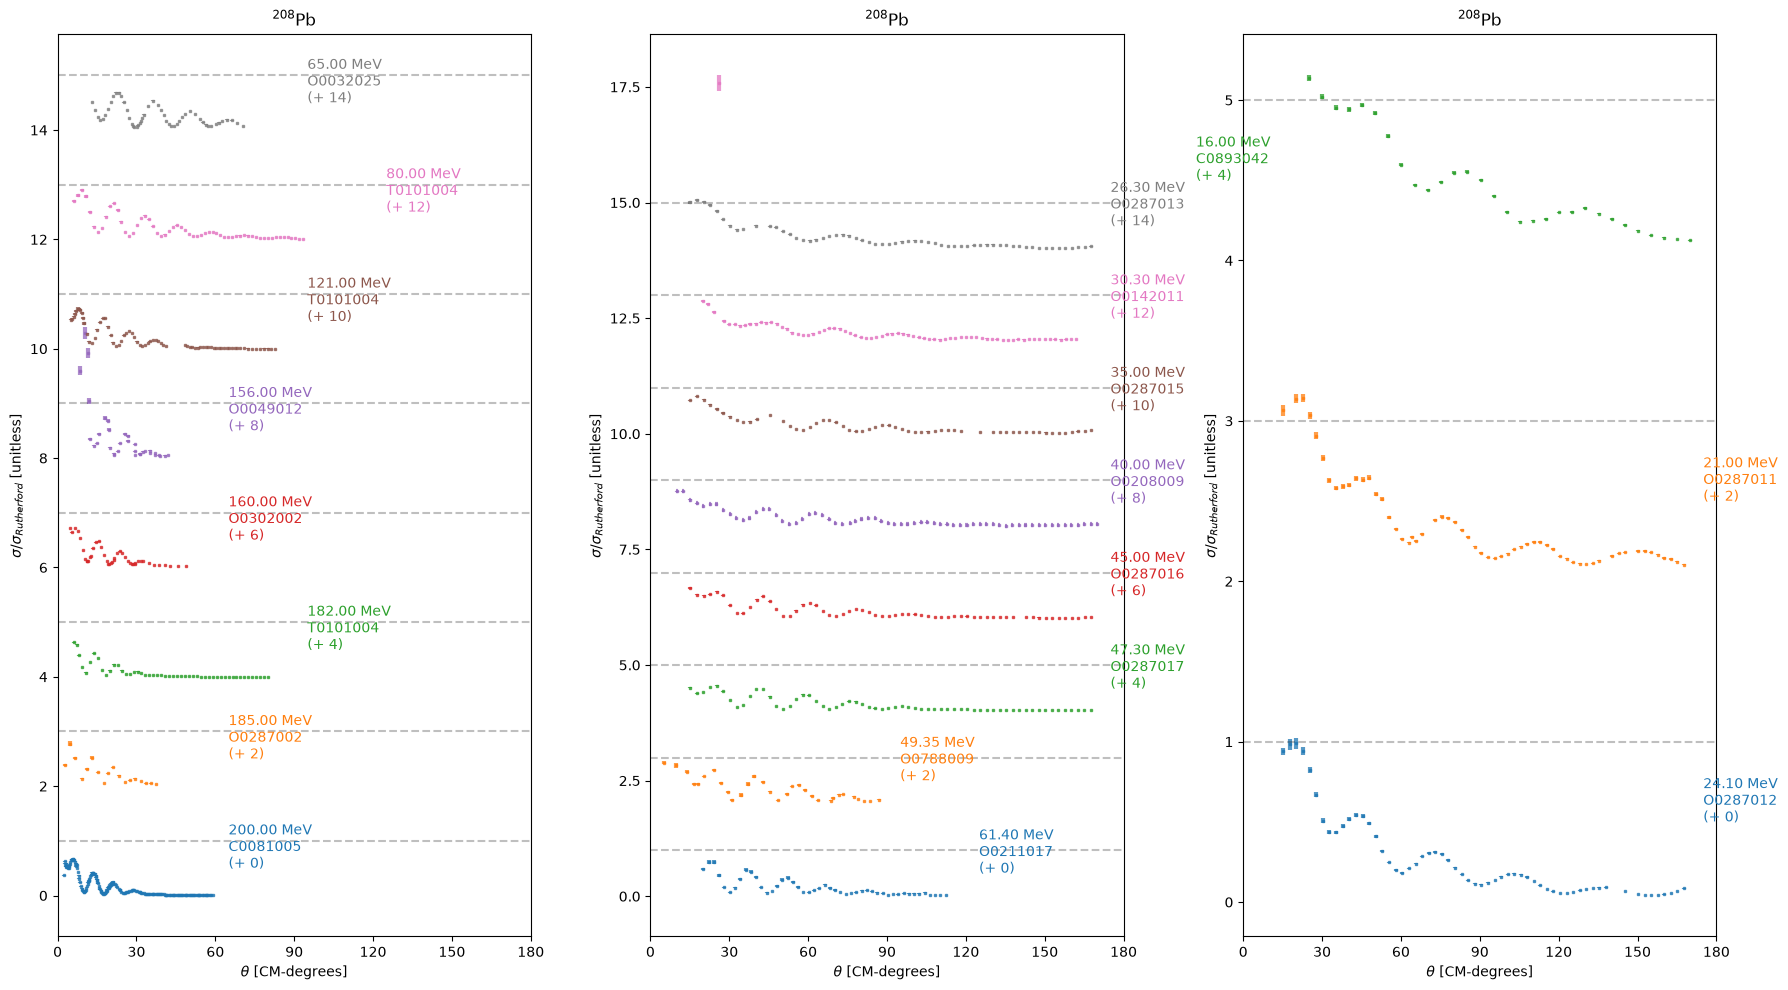

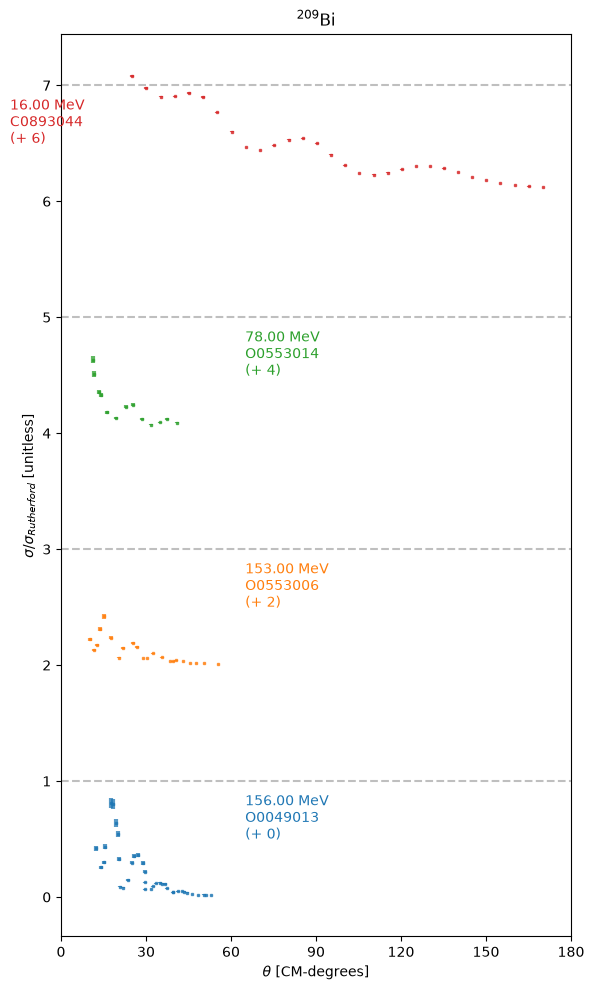

In [6]:
n_plotted = plotting.plot_sector(result)
assert n_plotted == len(result.records), (
    f"{len(result.records) - n_plotted} of {len(result.records)} data sets were not plotted")
print(f"plotted all {n_plotted} data sets")
plt.show()

## Write

`corpus.write` re-checks coverage against the allowlist before writing, so a data set
that silently disappears from EXFOR fails here rather than passing unnoticed.

In [7]:
corpus.write(result)
print(f"wrote {len(result.records)} measurements to data/{result.corpus}/{result.sector}/")

wrote 115 measurements to data/kduq/proton_elastic/
